In [1]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv("../data/cleaned/customers_clean.csv")
employees = pd.read_csv("../data/cleaned/employees_clean.csv")
menu = pd.read_csv("../data/cleaned/menu_clean.csv")
orders = pd.read_csv("../data/cleaned/orders_clean.csv")
order_details = pd.read_csv("../data/cleaned/order_details_clean.csv")


In [2]:
sales = (
    order_details
    .merge(menu, on="Item_ID")
    .merge(orders, on="Order_ID")
    .merge(customers, on="Customer_ID")
    .merge(employees, on="Employee_ID")
)

In [3]:
sales.head()
sales.info()
sales.shape

<class 'pandas.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Order_Detail_ID  1013 non-null   int64
 1   Order_ID         1013 non-null   str  
 2   Item_ID          1013 non-null   int64
 3   Quantity         1013 non-null   int64
 4   Item_Name        1013 non-null   str  
 5   Category         1013 non-null   str  
 6   Cost_Price       1013 non-null   int64
 7   Selling_Price    1013 non-null   int64
 8   Customer_ID      1013 non-null   str  
 9   Employee_ID      1013 non-null   str  
 10  Order_Date       1013 non-null   str  
 11  Order_Time       1013 non-null   str  
 12  Payment_Method   1013 non-null   str  
 13  Order_Type       1013 non-null   str  
 14  Name             1013 non-null   str  
 15  Gender           1013 non-null   str  
 16  Age              1013 non-null   int64
 17  City             1013 non-null   str  
 18  Member           10

(1013, 21)

In [4]:
sales["Revenue"] = sales["Quantity"] * sales["Selling_Price"]

sales["Profit"] = (
    sales["Selling_Price"] - sales["Cost_Price"]
) * sales["Quantity"]

In [ ]:
#HIGHEST REVENUE

In [5]:
category_revenue = (
    sales.groupby("Category")["Revenue"]
         .sum()
         .sort_values(ascending=False)
)

category_revenue

Category
Coffee     119821
Food        95143
Dessert     66386
Tea         44601
Name: Revenue, dtype: int64

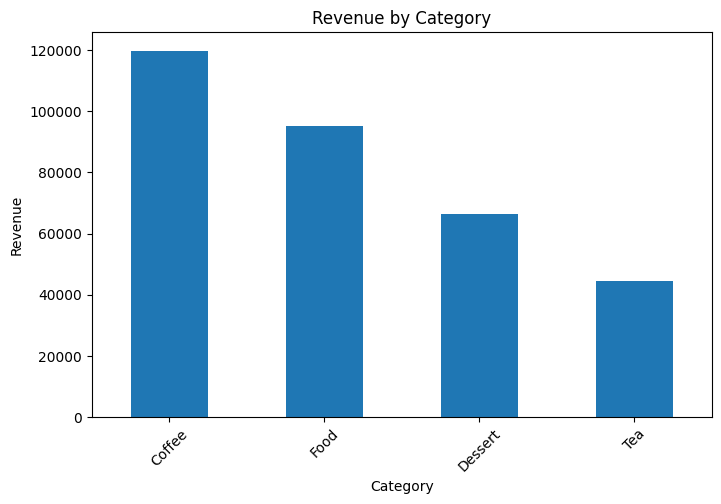

In [6]:
import matplotlib.pyplot as plt

category_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [7]:
sales["Profit"] = (
    sales["Selling_Price"] -
    sales["Cost_Price"]
) * sales["Quantity"]

In [8]:
sales["Revenue"].sum()

np.int64(325951)

In [9]:
sales["Profit"].sum()

np.int64(167427)

In [10]:
category_sales = (
    sales.groupby("Category")["Revenue"]
         .sum()
         .sort_values(ascending=False)
)

category_sales

Category
Coffee     119821
Food        95143
Dessert     66386
Tea         44601
Name: Revenue, dtype: int64

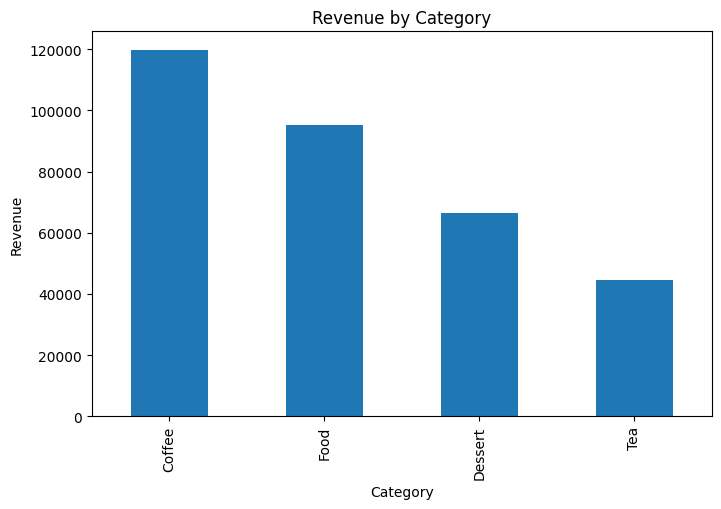

In [11]:
category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [12]:
top_products = (
    sales.groupby("Item_Name")["Quantity"]
         .sum()
         .sort_values(ascending=False)
         .head(10)
)

top_products

Item_Name
Americano          156
Cheesecake         154
Cappuccino         140
Muffin             139
Flat White         138
Paneer Sandwich    135
Green Tea          129
Latte              127
Brownie            124
Burger             124
Name: Quantity, dtype: int64

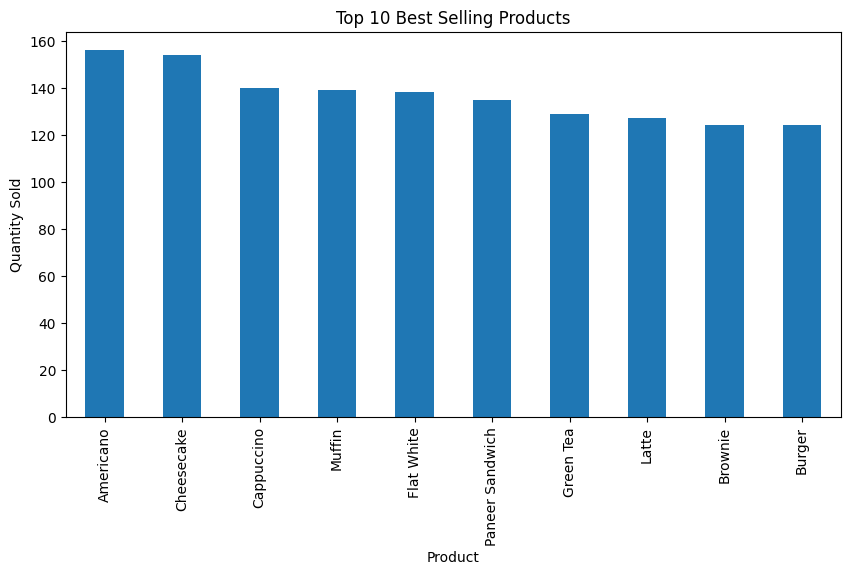

In [13]:
top_products.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

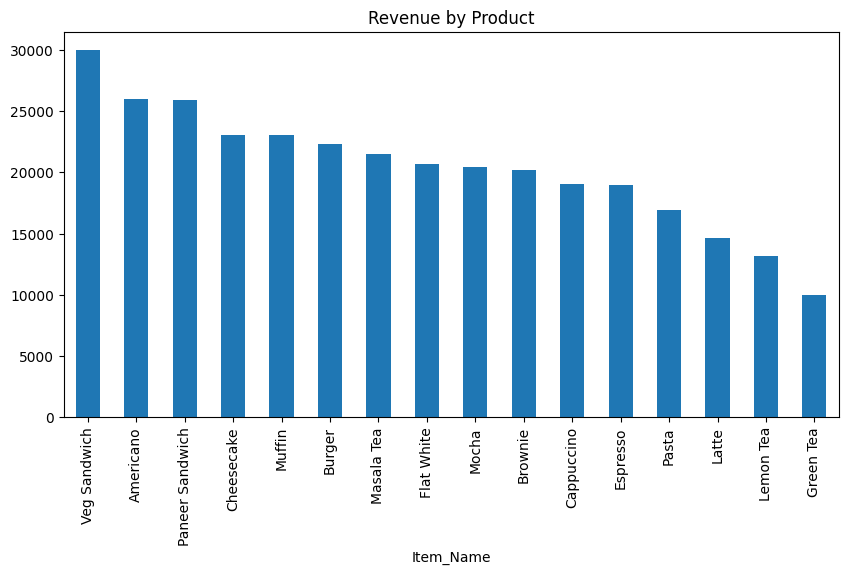

In [14]:
product_revenue = (
    sales.groupby("Item_Name")["Revenue"]
         .sum()
         .sort_values(ascending=False)
)

product_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Product")
plt.show()

In [15]:
payment = (
    sales.groupby("Payment_Method")
         .size()
)

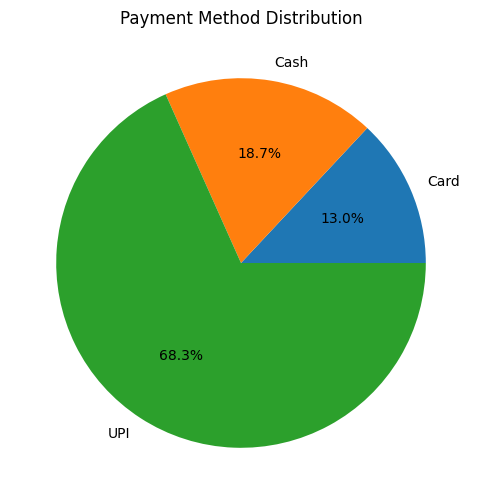

In [16]:
payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

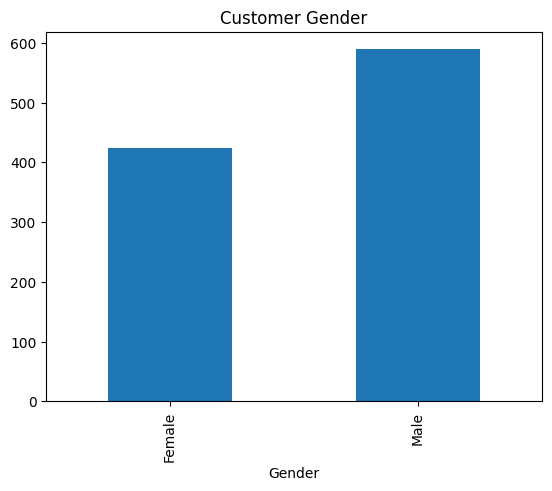

In [17]:
gender = (
    sales.groupby("Gender")
         .size()
)

gender.plot(
    kind="bar"
)

plt.title("Customer Gender")
plt.show()

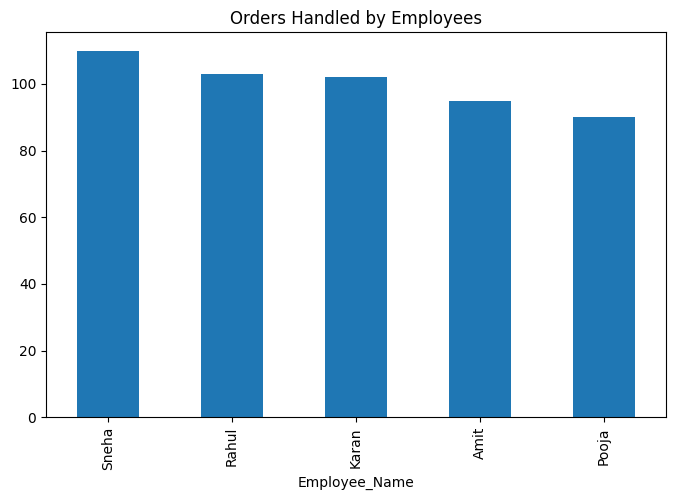

In [18]:
employee = (
    sales.groupby("Employee_Name")["Order_ID"]
         .nunique()
         .sort_values(ascending=False)
)

employee.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders Handled by Employees")
plt.show()

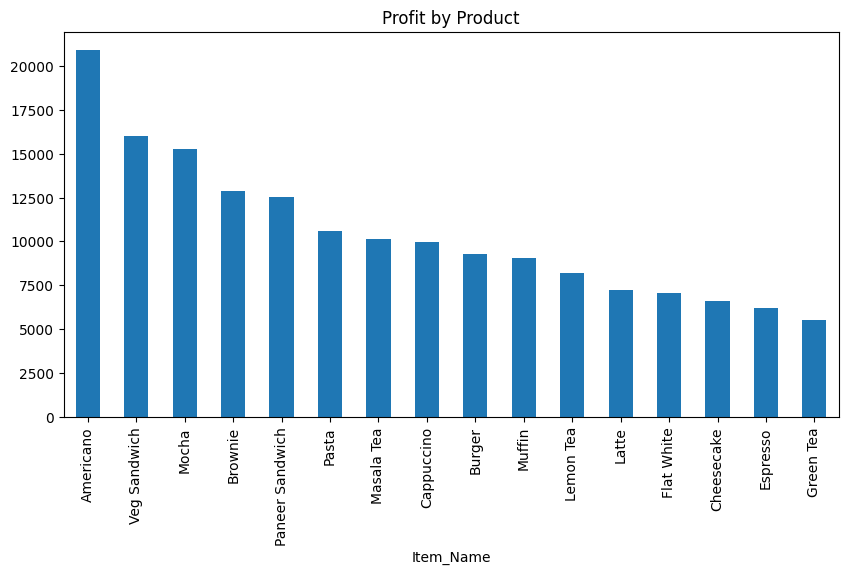

In [19]:
profit = (
    sales.groupby("Item_Name")["Profit"]
         .sum()
         .sort_values(ascending=False)
)

profit.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Profit by Product")
plt.show()

In [20]:
sales["Order_Date"] = pd.to_datetime(sales["Order_Date"])
sales["Month"] = sales["Order_Date"].dt.month_name()

In [21]:
monthly = (
    sales.groupby("Month")["Revenue"]
         .sum()
)

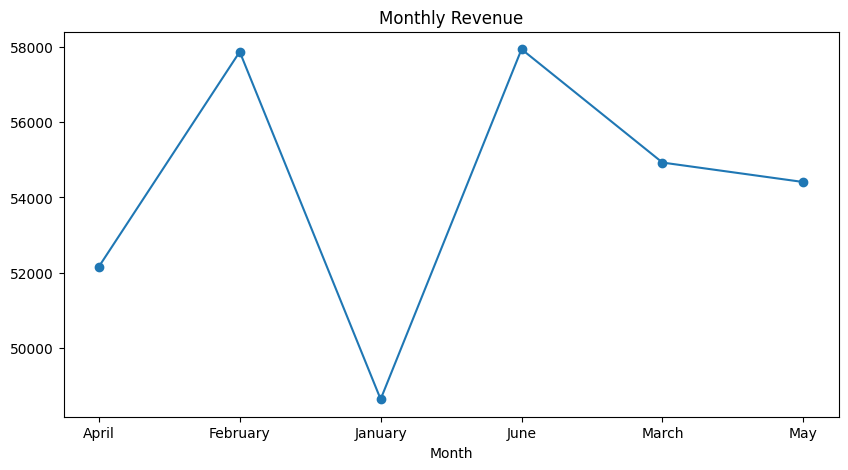

In [22]:
monthly.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Revenue")
plt.show()

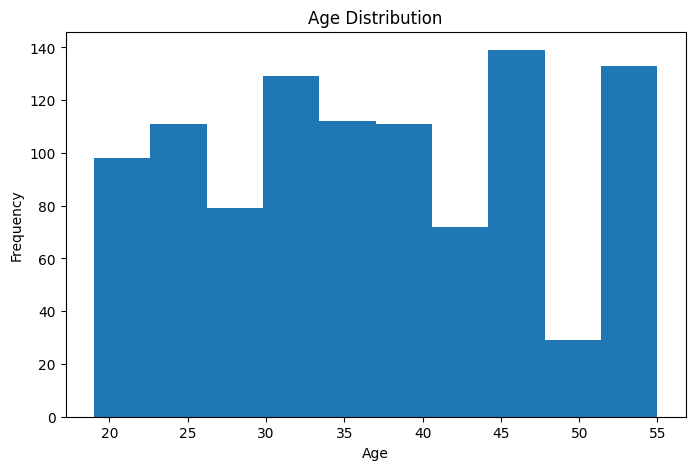

In [23]:
sales["Age"].plot(
    kind="hist",
    bins=10,
    figsize=(8,5)
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

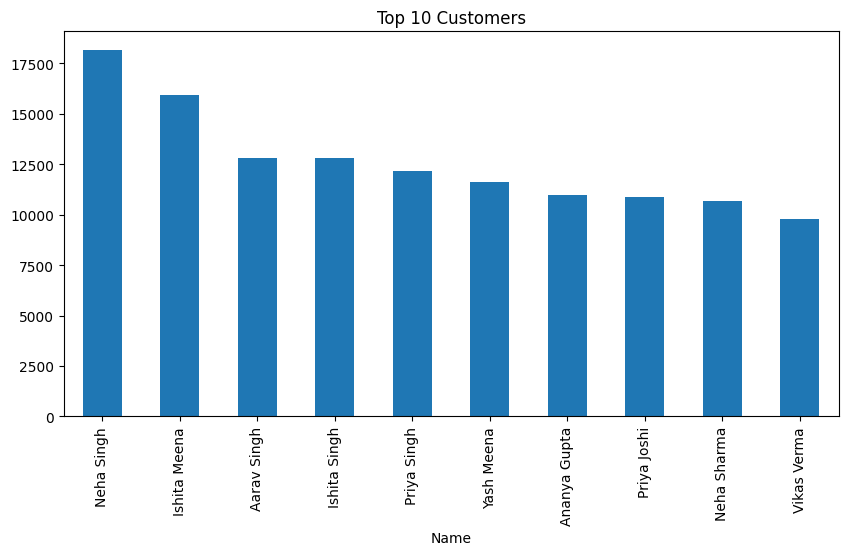

In [24]:
customer = (
    sales.groupby("Name")["Revenue"]
         .sum()
         .sort_values(ascending=False)
         .head(10)
)

customer.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers")
plt.show()